# Домашнее задание 3. NER для FactRuEval-2016

In [1]:
import gc
import importlib
import json
import logging
import math
import os
import random
import re
import sys
import urllib.request
from pathlib import Path
from typing import Any

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset, DatasetDict, concatenate_datasets, load_dataset
from deeppavlov import build_model
from IPython.display import display
from razdel import sentenize, tokenize
from seqeval.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import (
    AutoModelForMaskedLM,
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("WANDB_DISABLED", "true")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")


def find_repo_root(start: Path | None = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start_path


RANDOM_STATE = 42
ROOT = find_repo_root()
ARTIFACT_ROOT = ROOT / "artifacts" / "hw3"
RESULTS_PATH = ARTIFACT_ROOT / "results.jsonl"
BASE_MODEL_ID = "DeepPavlov/rubert-base-cased"
LENTA_PATH = ROOT / "data" / "lenta-ru-news.csv.gz"
LENTA_URL = "https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz"
ENTITY_ALIASES = {
    "PERSON": "PER",
    "PER": "PER",
    "ORG": "ORG",
    "ORGANIZATION": "ORG",
    "LOC": "LOC",
    "LOCATION": "LOC",
    "GPE": "LOC",
}

ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")


def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def release_torch_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


## 1. Обучить базовую модель NER

### 1.1 Загрузка данных

In [2]:
def flatten_factrueval(seed: int = RANDOM_STATE) -> DatasetDict:
    raw = load_dataset("gusevski/factrueval2016")
    split_map: dict[str, Dataset] = {}
    for split_name, split_ds in raw.items():
        rows = split_ds[0]["data"]
        split_map[split_name] = Dataset.from_dict(
            {
                "tokens": [item["tokens"] for item in rows],
                "ner_tags_str": [item["ner_tags_str"] for item in rows],
            }
        ).shuffle(seed=seed)
    return DatasetDict(split_map)


raw_ds = flatten_factrueval()
display(pd.DataFrame({"split": list(raw_ds.keys()), "sentences": [len(raw_ds[s]) for s in raw_ds.keys()]}))
display(pd.DataFrame(raw_ds["train"][:3]))
label_names = sorted({label for split in raw_ds.values() for row in split["ner_tags_str"] for label in row})
print("Labels:", label_names)

,split,sentences
0,train,7746
1,validation,2582
2,test,2582


,tokens,ner_tags_str
0,"[В, апреле, 2013, года, Худайнатов, был, назна...","[O, O, O, O, B-PER, O, O, O, O, O, O, O, O, O,..."
1,"[Уточняется, ,, что, как, В.Сердюков, ,, так, ...","[O, O, O, O, B-PER, O, O, O, B-PER, O, O, O, O..."
2,"[В, сообщении, ,, подписанном, лидерами, двух,...","[O, O, O, O, O, O, O, O, O, O, O, B-PER, O, O,..."


Labels: ['B-LOC', 'B-ORG', 'B-PER', 'I-LOC', 'I-ORG', 'I-PER', 'O']


### 1.2 Предобработка

Не делаем дополнительную очиску данных, так как я уже заранее попробовал и это ухудшило метрики.

Я выбрал `DeepPavlov/rubert-base-cased` в качестве базовой модели.

In [3]:
base_model_id = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(base_model_id)

id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

Делаем выравнивание меток

In [4]:
def tokenize_and_align_labels(examples, max_length=256):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
    )

    aligned_labels = []
    for i in range(len(examples["tokens"])):
        word_ids = tokenized.word_ids(batch_index=i)
        gold = examples["ner_tags_str"][i]
        prev = None
        out = []
        for w in word_ids:
            if w is None:
                out.append(-100)
            elif w != prev:
                out.append(label2id[gold[w]])
            else:
                # стандартно: продолжения слова игнорируем
                out.append(-100)
            prev = w
        aligned_labels.append(out)

    tokenized["labels"] = aligned_labels
    return tokenized

Посмотрим какой длины у нас последовательности.

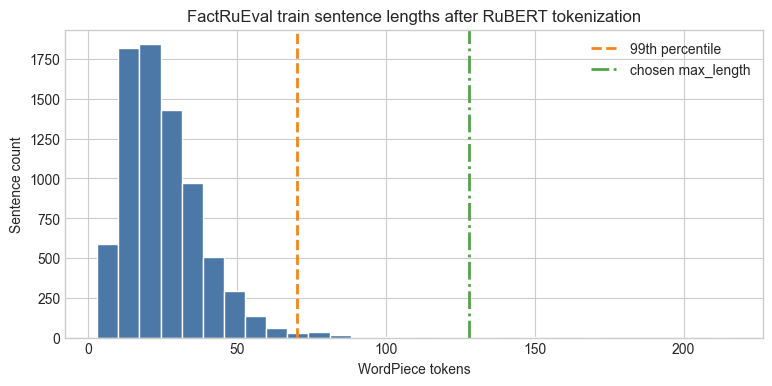

,quantile,length
0,50,23
1,75,32
2,90,43
3,95,49
4,99,70
5,100,216


Mean length: 25.52


In [5]:
train_wordpiece_lengths = [
    len(tokenizer(tokens, is_split_into_words=True)["input_ids"])
    for tokens in raw_ds["train"]["tokens"]
]

plt.figure(figsize=(9, 4))
plt.hist(train_wordpiece_lengths, bins=30, color="#4C78A8", edgecolor="white")
plt.axvline(70, color="#F58518", linestyle="--", linewidth=2, label="99th percentile")
plt.axvline(128, color="#54A24B", linestyle="-.", linewidth=2, label="chosen max_length")
plt.title("FactRuEval train sentence lengths after RuBERT tokenization")
plt.xlabel("WordPiece tokens")
plt.ylabel("Sentence count")
plt.legend()
plt.show()

display(
    pd.DataFrame(
        {
            "quantile": [50, 75, 90, 95, 99, 100],
            "length": [int(np.percentile(train_wordpiece_lengths, q)) for q in [50, 75, 90, 95, 99, 100]],
        }
    )
)
print("Mean length:", round(float(np.mean(train_wordpiece_lengths)), 2))

99-й перцентиль здесь находится примерно около 70 wordpiece-токенов. Поэтому `max_length=128` покрывает почти весь корпус с запасом и при этом не замедляет обучение так, как более консервативный потолок `256`.

In [6]:
max_length=128
tokenized = raw_ds.map(lambda x: tokenize_and_align_labels(x, max_length=max_length), batched=True)
# NER forward не принимает offset_mapping; Whole-Word MLM коллатору оно нужно — держим в tokenized, убираем копию.
tokenized_ner = tokenized.remove_columns(["offset_mapping"])
tokenized

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags_str', 'input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 7746
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags_str', 'input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 2582
    })
    test: Dataset({
        features: ['tokens', 'ner_tags_str', 'input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 2582
    })
})

Добавим паддинги по самой длинной последовательности в батче.

In [7]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding="longest")

### 1.3 Обучение базовой NER модели

Функции для вычисления метрик для NER. Сосредоточимся на `f1`, а также посмотрим на `precision` и `recall`.

In [8]:
seqeval_metric = evaluate.load("seqeval")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    y_true, y_pred = [], []
    for p, l in zip(preds, labels):
        true_labels = []
        pred_labels = []
        for pi, li in zip(p, l):
            if li == -100:
                continue
            true_labels.append(id2label[li])
            pred_labels.append(id2label[pi])
        y_true.append(true_labels)
        y_pred.append(pred_labels)

    res = seqeval_metric.compute(predictions=y_pred, references=y_true, zero_division=0)
    return {
        "f1": res["overall_f1"],
        "precision": res["overall_precision"],
        "recall": res["overall_recall"],
    }


def get_metrics_from_predict(prediction_output):
    m = prediction_output.metrics
    return {
        "f1": m["test_f1"],
        "precision": m["test_precision"],
        "recall": m["test_recall"],
    }

Функции для загрузки и сохранения моделей. Модели обучались очень долго, поэтому некоторые я загружаю из кеша, чтобы можно было быстро перезапускать notebook, а не ждать по несколько часов.

In [9]:
def append_result(payload: dict[str, Any]) -> None:
    RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with RESULTS_PATH.open("a", encoding="utf-8") as f:
        f.write(json.dumps(payload, ensure_ascii=False) + "\n")


def latest_result(model_name: str) -> dict[str, Any] | None:
    if not RESULTS_PATH.exists():
        return None
    for line in reversed(RESULTS_PATH.read_text(encoding="utf-8").splitlines()):
        if not line.strip():
            continue
        row = json.loads(line)
        if row["model_name"] == model_name:
            return row
    return None


Вспомогательные функции для обработки результатов.

In [10]:
def split_metrics(result: dict[str, Any]) -> dict[str, dict[str, float]]:
    return {
        "validation": {
            key.removeprefix("validation_"): float(value)
            for key, value in result["validation_metrics"].items()
        },
        "test": {
            key.removeprefix("test_"): float(value)
            for key, value in result["target_metrics"].items()
        },
    }


def make_experiment_summary(
    model_name: str,
    artifact_dir: Path | str,
    validation_metrics: dict[str, float],
    test_metrics: dict[str, float],
) -> dict[str, Any]:
    return {
        "model_name": model_name,
        "artifact_dir": str(artifact_dir),
        "validation_metrics": {f"validation_{k}": float(v) for k, v in validation_metrics.items()},
        "target_metrics": {f"test_{k}": float(v) for k, v in test_metrics.items()},
    }


def make_mlm_summary(model_name: str, artifact_dir: Path | str, eval_loss: float) -> dict[str, Any]:
    return {
        "model_name": model_name,
        "artifact_dir": str(artifact_dir),
        "eval_loss": float(eval_loss),
        "perplexity": float(math.exp(eval_loss)),
    }

По гипперпараметрам для NER:

- LR и Scheduler: 2.5e-5 с cosine: чуть повышенный LR + косинусный график который обычно дает более плавную сходимость.
- weight_decay = 0.01: дефолтная регуляризация
- warmup_steps = 58: подобрал путем перебора

In [11]:
def make_ner_trainer(
    model,
    output_dir: Path | str,
    *,
    train_dataset=None,
    eval_dataset=None,
    training_kwargs: dict[str, Any] | None = None,
    patience: int = 3,
) -> Trainer:
    args_kwargs = {
        "output_dir": str(output_dir),
        "learning_rate": 2.5e-5,
        "warmup_steps": 58,
        "lr_scheduler_type": "cosine",
        "weight_decay": 0.01,
        "per_device_train_batch_size": 16,
        "per_device_eval_batch_size": 32,
        "gradient_accumulation_steps": 2,
        "num_train_epochs": 3,
        "fp16": torch.cuda.is_available(),
        "dataloader_pin_memory": torch.cuda.is_available(),
        "eval_strategy": "steps",
        "save_strategy": "steps",
        "logging_steps": 50,
        "eval_steps": 200,
        "save_steps": 200,
        "save_total_limit": 2,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
        "greater_is_better": True,
        "report_to": "none",
    }
    if training_kwargs:
        args_kwargs.update(training_kwargs)
    args = TrainingArguments(**args_kwargs)
    return Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset or tokenized_ner["train"],
        eval_dataset=eval_dataset or tokenized_ner["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
    )


def train_or_load_ner_experiment(
    model_name: str,
    output_dir: Path | str,
    init_from: Path | str,
    *,
    train_dataset=None,
    training_kwargs: dict[str, Any] | None = None,
    patience: int = 3,
) -> tuple[dict[str, Any], dict[str, dict[str, float]]]:
    cached_result = latest_result(model_name)
    if cached_result is not None:
        print(f"Загружаю {model_name} из result-cache: {cached_result['artifact_dir']}")
        return cached_result, split_metrics(cached_result)

    model = AutoModelForTokenClassification.from_pretrained(
        str(init_from),
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
    )
    trainer = make_ner_trainer(
        model,
        output_dir,
        train_dataset=train_dataset,
        training_kwargs=training_kwargs,
        patience=patience,
    )
    set_seed()
    trainer.train()
    trainer.save_model(str(output_dir))

    metrics = {
        "validation": get_metrics_from_predict(trainer.predict(tokenized_ner["validation"])),
        "test": get_metrics_from_predict(trainer.predict(tokenized_ner["test"])),
    }
    result = make_experiment_summary(model_name, output_dir, metrics["validation"], metrics["test"])
    append_result(result)

    del trainer
    del model
    gc.collect()
    release_torch_memory()
    return result, metrics


Собственно обучение базовой модели:

In [12]:
baseline_model_name = "supervised_baseline"
base_model_dir = ARTIFACT_ROOT / "base_model"

base_model_before = AutoModelForTokenClassification.from_pretrained(
    base_model_id,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
base_model_before_trainer = make_ner_trainer(base_model_before, base_model_dir)
metrics = {
    "validation": {"before": get_metrics_from_predict(base_model_before_trainer.predict(tokenized_ner["validation"]))},
    "test": {"before": get_metrics_from_predict(base_model_before_trainer.predict(tokenized_ner["test"]))},
}

del base_model_before_trainer
del base_model_before
gc.collect()
release_torch_memory()

baseline, after_metrics = train_or_load_ner_experiment(
    baseline_model_name,
    base_model_dir,
    base_model_id,
)
metrics["validation"]["after"] = after_metrics["validation"]
metrics["test"]["after"] = after_metrics["test"]

comparison = pd.DataFrame(
    [
        metrics["validation"]["before"],
        metrics["validation"]["after"],
        metrics["test"]["before"],
        metrics["test"]["after"],
    ],
    index=pd.MultiIndex.from_tuples(
        [
            ("validation", "до обучения"),
            ("validation", "после обучения"),
            ("test", "до обучения"),
            ("test", "после обучения"),
        ],
        names=["split", "фаза"],
    ),
)
display(comparison)



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

Загружаю supervised_baseline из result-cache: /Users/aleksejlapin/ITMO/DL-NLP-course/artifacts/hw3/base_model


f1  precision    recall
split      фаза                                         
validation до обучения     0.032499   0.018544  0.131350
           после обучения  0.978793   0.976910  0.980684
test       до обучения     0.030672   0.017541  0.121987
           после обучения  0.981520   0.978581  0.984478

Видим, что уже у базовой модели очень сильные метрики. В дальнейшем будем бороться уже даже за небольшое улучшение.

## 2. MLM до NER

Обучим модель MLM на базовой модели, а потом на NER и сравним качество

In [13]:
def make_mlm_trainer(
    model,
    output_dir: Path | str,
    train_dataset,
    eval_dataset,
    data_collator,
) -> Trainer:
    """Общие TrainingArguments и Trainer для MLM (случайные маски / WWM / concept)."""
    args = TrainingArguments(
        output_dir=str(output_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        learning_rate=2e-5,
        num_train_epochs=3,
        weight_decay=0.01,
        disable_tqdm=True,
        # Иначе Trainer выкидывает offset_mapping / word_ids до коллатора (их нет в forward MLM).
        remove_unused_columns=False,
        dataloader_pin_memory=torch.cuda.is_available(),
    )
    return Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
    )


def train_or_load_mlm_experiment(
    model_name: str,
    output_dir: Path | str,
    init_from: Path | str,
    train_dataset,
    eval_dataset,
    data_collator,
) -> dict[str, Any]:
    cached_result = latest_result(model_name)
    if cached_result is not None:
        print(f"Загружаю {model_name} из result-cache: {cached_result['artifact_dir']}")
        return cached_result

    model = AutoModelForMaskedLM.from_pretrained(str(init_from))
    trainer = make_mlm_trainer(
        model,
        output_dir,
        train_dataset,
        eval_dataset,
        data_collator,
    )
    set_seed()
    trainer.train()
    trainer.save_model(str(output_dir))
    eval_results = trainer.evaluate()
    result = make_mlm_summary(model_name, output_dir, eval_results["eval_loss"])
    append_result(result)

    del trainer
    del model
    gc.collect()
    release_torch_memory()
    return result

### 2.1 MLM с маскированием рандомных токенов

Задаем маскирование. С шансом 0,15 каждая позиция выбирается для задачи MLM.

In [14]:
data_collator_mlm = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
)

Убираем лишние колонки, чтобы не тратить память.

In [15]:
def tokenize_for_wwm(examples, max_length=128):
    return tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_offsets_mapping=True,
    )


mlm_train = tokenized["train"].remove_columns(["tokens", "ner_tags_str", "offset_mapping", "labels"])
mlm_eval = tokenized["validation"].remove_columns(["tokens", "ner_tags_str", "offset_mapping", "labels"])

tokenized_wwm = raw_ds.map(lambda x: tokenize_for_wwm(x, max_length=max_length), batched=True)
mlm_train_wwm = tokenized_wwm["train"].remove_columns(["tokens", "ner_tags_str"])
mlm_eval_wwm = tokenized_wwm["validation"].remove_columns(["tokens", "ner_tags_str"])


Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

In [16]:
mlm_result = train_or_load_mlm_experiment(
    "mlm_random_tokens",
    ARTIFACT_ROOT / "mlm_random_tokens",
    base_model_id,
    mlm_train,
    mlm_eval,
    data_collator_mlm,
)
print(f"Perplexity: {mlm_result['perplexity']:.2f}")
mlm_ckpt = mlm_result["artifact_dir"]

Загружаю mlm_random_tokens из result-cache: /Users/aleksejlapin/ITMO/DL-NLP-course/artifacts/hw3/mlm_random_tokens
Perplexity: 4.93


Хорошое значение по perplexity, значит модель выберает в среднем из 5 возможных вариантов, что довольно хороший показатель.

Дообучение NER после MLM

Энкодер загружаем из лучшего MLM-чекпойнта, голову token classification создаём заново. Гиперпараметры как в п. 1.3, чтобы сравнение с прямым NER без промежуточного MLM было сопоставимым.

In [17]:
ner_from_mlm_standard, metrics_ner_mlm = train_or_load_ner_experiment(
    "standard_mlm_then_ner",
    ARTIFACT_ROOT / "ner_after_mlm_random",
    mlm_ckpt,
)

compare_mlm = pd.DataFrame(
    [
        {**metrics["validation"]["after"], "этап": "NER без MLM (val)"},
        {**metrics_ner_mlm["validation"], "этап": "MLM → NER (val)"},
        {**metrics["test"]["after"], "этап": "NER без MLM (test)"},
        {**metrics_ner_mlm["test"], "этап": "MLM → NER (test)"},
    ]
).set_index("этап")
display(compare_mlm)

Загружаю standard_mlm_then_ner из result-cache: /Users/aleksejlapin/ITMO/DL-NLP-course/artifacts/hw3/ner_after_mlm_random


,f1,precision,recall
этап,,,
NER без MLM (val),0.978793,0.976910,0.980684
MLM → NER (val),0.980528,0.978642,0.982422
NER без MLM (test),0.981520,0.978581,0.984478
MLM → NER (test),0.980778,0.978549,0.983017


Видим, что есть небольшой регресс на метриках относительной базовой модели.

### 2.2 MLM с маскированием целых слов

In [18]:
data_collator_mlm_wwm = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    whole_word_mask=True,
    mlm_probability=0.15,
)


/Users/aleksejlapin/ITMO/DL-NLP-course/.venv/lib/python3.10/site-packages/transformers/data/data_collator.py:722: UserWarning: Random token replacement is not supported with whole word masking. Setting mask_replace_prob to 1.
  warnings.warn(


In [19]:
mlm_whole_words_result = train_or_load_mlm_experiment(
    "mlm_whole_words",
    ARTIFACT_ROOT / "mlm_whole_words",
    base_model_id,
    mlm_train_wwm,
    mlm_eval_wwm,
    data_collator_mlm_wwm,
)
print(f"Perplexity: {mlm_whole_words_result['perplexity']:.2f}")
mlm_ckpt_whole_words = mlm_whole_words_result["artifact_dir"]


Загружаю mlm_whole_words из result-cache: /Users/aleksejlapin/ITMO/DL-NLP-course/artifacts/hw3/mlm_whole_words
Perplexity: 13.11


In [20]:
ner_from_mlm_whole_words, metrics_ner_mlm_whole_words = train_or_load_ner_experiment(
    "whole_word_mlm_then_ner",
    ARTIFACT_ROOT / "ner_after_mlm_whole_words",
    mlm_ckpt_whole_words,
)

compare_mlm = pd.DataFrame(
    [
        {**metrics["validation"]["after"], "этап": "NER без MLM (val)"},
        {**metrics_ner_mlm_whole_words["validation"], "этап": "MLM whole words → NER (val)"},
        {**metrics["test"]["after"], "этап": "NER без MLM (test)"},
        {**metrics_ner_mlm_whole_words["test"], "этап": "MLM whole words → NER (test)"},
    ]
).set_index("этап")
display(compare_mlm)

Загружаю whole_word_mlm_then_ner из result-cache: /Users/aleksejlapin/ITMO/DL-NLP-course/artifacts/hw3/ner_after_mlm_whole_words


,f1,precision,recall
этап,,,
NER без MLM (val),0.978793,0.976910,0.980684
MLM whole words → NER (val),0.977371,0.974462,0.980297
NER без MLM (test),0.981520,0.978581,0.984478
MLM whole words → NER (test),0.981318,0.979443,0.983199


Видим небольшой регресс относительно базовой модели по f1 и recall, зато мы немного повысили точность.

### 2.3 MLM с concept masking (маскирование NER-сущностей)

В отличие от случайного MLM или whole-word, **маскируем только токены слов с NER-меткой не `O`** (все субтокены такого слова сразу). Модель учится предсказывать пропуски внутри сущностей.

Для коллатора нужны `word_ids` (индекс исходного слова) и выровненные NER-метки; `labels` переименовываем в `ner_label_ids`, чтобы не пересекаться с целевыми id токенов в MLM.

In [21]:
def tokenize_for_concept_mlm(examples, max_length=128):
    encoded = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_length,
    )

    word_ids_batch, ner_label_ids_batch = [], []
    for i, gold in enumerate(examples["ner_tags_str"]):
        word_ids = encoded.word_ids(batch_index=i)
        row_word_ids, row_ner_label_ids = [], []
        previous_word_id = None
        for word_id in word_ids:
            row_word_ids.append(-1 if word_id is None else word_id)
            if word_id is None:
                row_ner_label_ids.append(-100)
            elif word_id != previous_word_id:
                row_ner_label_ids.append(label2id[gold[word_id]])
            else:
                row_ner_label_ids.append(-100)
            previous_word_id = word_id
        word_ids_batch.append(row_word_ids)
        ner_label_ids_batch.append(row_ner_label_ids)

    encoded["word_ids"] = word_ids_batch
    encoded["ner_label_ids"] = ner_label_ids_batch
    return encoded



def concept_mlm_split(name):
    return raw_ds[name].map(
        lambda x: tokenize_for_concept_mlm(x, max_length=max_length),
        batched=True,
        remove_columns=raw_ds[name].column_names,
    )



class DataCollatorForConceptMask(DataCollatorForLanguageModeling):
    # Вероятность mlm_probability задаётся только на позициях сущностей; дальше — стандартная схема 80/10/10 от родителя.
    def __init__(self, tokenizer, o_label_id, **kw):
        super().__init__(tokenizer, **kw)
        self.o = o_label_id

    def torch_call(self, ex):
        if self.seed and self.generator is None:
            self.create_rng()
        b = self.tokenizer.pad(ex, padding=True, pad_to_multiple_of=self.pad_to_multiple_of, return_tensors="pt")
        ner, wid = b.pop("ner_label_ids"), b.pop("word_ids")
        attn = b["attention_mask"]
        wid, ner = wid.masked_fill(attn == 0, -1), ner.masked_fill(attn == 0, -100)
        b.pop("special_tokens_mask", None)
        x = b["input_ids"]
        ent = torch.zeros_like(x, dtype=torch.bool)
        for i in range(x.size(0)):
            w, n, seen = wid[i], ner[i], set()
            for t in range(w.numel()):
                j = int(w[t])
                if j < 0 or j in seen:
                    continue
                seen.add(j)
                if int(n[t]) not in (-100, self.o):
                    ent[i] |= w == j
        p = ent.float() * self.mlm_probability
        stm = torch.tensor(
            [self.tokenizer.get_special_tokens_mask(v, already_has_special_tokens=True) for v in x.tolist()],
            dtype=torch.bool,
        )
        p.masked_fill_(stm, 0)
        pid = self.tokenizer.pad_token_id
        if pid is not None:
            p.masked_fill_(x == pid, 0)
        mi = torch.bernoulli(p, generator=self.generator).bool()
        y = x.clone()
        y[~mi] = -100
        ir = torch.bernoulli(torch.full_like(y, self.mask_replace_prob, dtype=torch.float), generator=self.generator).bool() & mi
        x = x.clone()
        x[ir] = self.tokenizer.mask_token_id
        rem = 1 - self.mask_replace_prob
        rs = self.random_replace_prob / rem if rem > 0 else 0.0
        ig = torch.bernoulli(torch.full_like(y, rs, dtype=torch.float), generator=self.generator).bool() & mi & ~ir
        rw = torch.randint(len(self.tokenizer), y.shape, dtype=torch.long, device=x.device, generator=self.generator)
        x[ig] = rw[ig]
        b["input_ids"], b["labels"] = x, y
        return b


mlm_train_concept, mlm_eval_concept = concept_mlm_split("train"), concept_mlm_split("validation")
data_collator_mlm_concept = DataCollatorForConceptMask(tokenizer, label2id["O"], mlm=True, mlm_probability=0.15)


Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/2582 [00:00<?, ? examples/s]

MLM с concept-коллатором (гиперпараметры как у MLM в 2.1/2.2 для сопоставимости)

In [22]:
mlm_concept_result = train_or_load_mlm_experiment(
    "mlm_concept",
    ARTIFACT_ROOT / "mlm_concept",
    base_model_id,
    mlm_train_concept,
    mlm_eval_concept,
    data_collator_mlm_concept,
)
print(f"Perplexity: {mlm_concept_result['perplexity']:.2f}")
mlm_ckpt_concept = mlm_concept_result["artifact_dir"]



Загружаю mlm_concept из result-cache: /Users/aleksejlapin/ITMO/DL-NLP-course/artifacts/hw3/mlm_concept
Perplexity: nan


Загрузка лучшего MLM-чекпойнта и дообучение головы NER (как в 2.1 после MLM).

In [23]:
ner_from_mlm_concept, metrics_ner_mlm_concept = train_or_load_ner_experiment(
    "concept_mlm_full_then_ner",
    ARTIFACT_ROOT / "ner_after_mlm_concept",
    mlm_ckpt_concept,
)

compare_mlm = pd.DataFrame(
    [
        {**metrics["validation"]["after"], "этап": "NER без MLM (val)"},
        {**metrics_ner_mlm_concept["validation"], "этап": "MLM concept → NER (val)"},
        {**metrics["test"]["after"], "этап": "NER без MLM (test)"},
        {**metrics_ner_mlm_concept["test"], "этап": "MLM concept → NER (test)"},
    ]
).set_index("этап")
display(compare_mlm)



Загружаю concept_mlm_full_then_ner из result-cache: /Users/aleksejlapin/ITMO/DL-NLP-course/artifacts/hw3/ner_after_mlm_concept


,f1,precision,recall
этап,,,
NER без MLM (val),0.978793,0.976910,0.980684
MLM concept → NER (val),0.977649,0.975207,0.980104
NER без MLM (test),0.981520,0.978581,0.984478
MLM concept → NER (test),0.980024,0.979041,0.981008


Видим, что тут, как и с маскированием целых слов, мы немного улучшились по точности взамен полноты и F1.

## 3. Teacher для synthetic labeling

Для псевдоразметки использую только `DEEPPAVLOV_MODEL_NAME = "ner_collection3_bert"`.

У этой модели в текущей среде есть две не совместимости: `deeppavlov` ожидает импорт `torchcrf`, а старый checkpoint содержит лишний ключ `bert.embeddings.position_ids`. Поэтому ниже есть только минимальный patch runtime, после которого teacher стабильно работает.


In [24]:
DEEPPAVLOV_MODEL_NAME = "ner_collection3_bert"


def patch_deeppavlov_runtime() -> None:
    # DeepPavlov импортирует модуль как `torchcrf`, а в этом окружении пакет установлен как `TorchCRF`.
    import TorchCRF

    sys.modules.setdefault("torchcrf", TorchCRF)

    TorchModel = importlib.import_module("deeppavlov.core.models.torch_model").TorchModel
    if getattr(TorchModel, "_hw3_load_patch", False):
        return

    # Старый checkpoint содержит `bert.embeddings.position_ids`, который новый transformers не принимает.
    def patched_load(self: Any, fname: str | None = None, *args: Any, **kwargs: Any) -> None:
        if fname is not None:
            self.load_path = fname
        if self.load_path:
            weights_path = Path(self.load_path.resolve()).with_suffix(".pth.tar")
            if weights_path.exists():
                checkpoint = torch.load(weights_path, map_location=self.device)
                model_state = checkpoint["model_state_dict"]
                model_state.pop("bert.embeddings.position_ids", None)
                if all(key.startswith("module.") for key in model_state):
                    model_state = {key.replace("module.", "", 1): value for key, value in model_state.items()}
                target_model = self.model.module if getattr(self, "is_data_parallel", False) else self.model
                target_model.load_state_dict(model_state, strict=False)
                try:
                    self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
                except ValueError:
                    pass
                self.epochs_done = checkpoint.get("epochs_done", 0)
        self.model.to(self.device)

    TorchModel.load = patched_load
    TorchModel._hw3_load_patch = True



def build_spans(tokens: list[str]) -> list[tuple[int, int]]:
    spans = []
    cursor = 0
    for token in tokens:
        start = cursor
        cursor += len(token)
        spans.append((start, cursor))
        cursor += 1
    return spans



def normalize_deeppavlov_label(raw_label: str) -> str:
    if raw_label == "O":
        return "O"
    prefix, entity = raw_label.split("-", maxsplit=1)
    entity = ENTITY_ALIASES.get(entity.upper(), entity.upper())
    if entity not in {"PER", "ORG", "LOC"}:
        return "O"
    if prefix in {"S", "B"}:
        return f"B-{entity}"
    if prefix in {"E", "I"}:
        return f"I-{entity}"
    return "O"



def align_deeppavlov_prediction(gold_tokens: list[str], pred_tokens: list[str], pred_tags: list[str]) -> list[str]:
    gold_spans = build_spans(gold_tokens)
    pred_spans = build_spans(pred_tokens)
    aligned = ["O"] * len(gold_tokens)

    for pred_span, raw_tag in zip(pred_spans, pred_tags, strict=True):
        tag = normalize_deeppavlov_label(raw_tag)
        if tag == "O":
            continue
        prefix, entity = tag.split("-", maxsplit=1)
        wrote_label = False
        for idx, (gold_start, gold_end) in enumerate(gold_spans):
            if gold_end <= pred_span[0] or gold_start >= pred_span[1]:
                continue
            aligned[idx] = f"I-{entity}" if prefix == "B" and wrote_label else tag
            wrote_label = True
    return aligned



def predict_with_deeppavlov(sentences: list[list[str]], batch_size: int = 64) -> list[dict[str, Any]]:
    patch_deeppavlov_runtime()
    teacher = build_model(DEEPPAVLOV_MODEL_NAME, download=True)
    texts = [" ".join(tokens) for tokens in sentences]

    pred_tokens_batch, pred_tags_batch = [], []
    for start in range(0, len(texts), batch_size):
        batch_pred_tokens, batch_pred_tags = teacher(texts[start : start + batch_size])
        pred_tokens_batch.extend(batch_pred_tokens)
        pred_tags_batch.extend(batch_pred_tags)

    outputs = []
    for gold_tokens, pred_tokens, pred_tags in zip(sentences, pred_tokens_batch, pred_tags_batch, strict=True):
        labels = align_deeppavlov_prediction(gold_tokens, pred_tokens, pred_tags)
        outputs.append(
            {
                "tokens": gold_tokens,
                "ner_tags_str": labels,
                "entity_count": int(sum(label.startswith("B-") for label in labels)),
            }
        )

    del teacher
    gc.collect()
    release_torch_memory()
    return outputs



def run_deeppavlov_teacher_eval(split: str = "validation") -> dict[str, float]:
    rows = raw_ds[split]
    predictions = predict_with_deeppavlov(rows["tokens"])
    gold = rows["ner_tags_str"]
    pred = [item["ner_tags_str"] for item in predictions]
    return {
        "precision": float(precision_score(gold, pred)),
        "recall": float(recall_score(gold, pred)),
        "f1": float(f1_score(gold, pred)),
    }


In [25]:
teacher_metrics = run_deeppavlov_teacher_eval()
display(
    pd.DataFrame(
        [
            {
                "teacher": DEEPPAVLOV_MODEL_NAME,
                "validation_precision": teacher_metrics["precision"],
                "validation_recall": teacher_metrics["recall"],
                "validation_f1": teacher_metrics["f1"],
            }
        ]
    ).round(6)
)


2026-03-29 16:08:26.294 INFO in 'deeppavlov.download'['download'] at line 138: Skipped http://files.deeppavlov.ai/v1/ner/ner_rus_bert_coll3_torch.tar.gz download because of matching hashes


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

,teacher,validation_precision,validation_recall,validation_f1
0,ner_collection3_bert,0.767644,0.763814,0.765724


Метрики уступают базовой модели, но это лучшее, что мне удалось найти из внешних моделей. Пробовал GLiNER и tesemnikov-av/NER-RUBERT-Per-Loc-Org - они уступают ner_collection3_bert.

## 4. Обучение на синтетических данных

Сравниваю два варианта synthetic-data обучения: с внешним teacher `ner_collection3_bert` и с локальным teacher, где teacher = student = `supervised_baseline` (потому что студент изначально показывает результаты лучше учителя)


In [26]:
def collect_candidate_sentences(
    article_limit: int = 10000,
    max_sentences: int = 12000,
    max_sentence_length: int = 48,
) -> list[list[str]]:
    LENTA_PATH.parent.mkdir(parents=True, exist_ok=True)
    if not LENTA_PATH.exists():
        urllib.request.urlretrieve(LENTA_URL, LENTA_PATH)

    lenta_df = pd.read_csv(LENTA_PATH, usecols=["title", "text"], nrows=article_limit)
    texts = lenta_df["title"].fillna("").astype(str).tolist() + lenta_df["text"].fillna("").astype(str).tolist()

    candidate_sentences: list[list[str]] = []
    for text in texts:
        if len(candidate_sentences) >= max_sentences:
            break
        for sent in sentenize(text):
            normalized = re.sub(r"\s+", " ", sent.text).strip()
            if not normalized:
                continue
            tokens = [item.text for item in tokenize(normalized)]
            if 4 <= len(tokens) <= max_sentence_length:
                candidate_sentences.append(tokens)
            if len(candidate_sentences) >= max_sentences:
                break
    return candidate_sentences


candidate_sentences = collect_candidate_sentences()


def build_pseudo_train_split(predict_fn, top_k: int = 3000) -> tuple[Dataset, list[dict[str, Any]]]:
    pseudo_records = [item for item in predict_fn(candidate_sentences) if item["entity_count"] > 0][:top_k]
    pseudo_ds = Dataset.from_dict(
        {
            "tokens": [item["tokens"] for item in pseudo_records],
            "ner_tags_str": [item["ner_tags_str"] for item in pseudo_records],
        }
    )
    pseudo_train = concatenate_datasets([raw_ds["train"], pseudo_ds]).shuffle(seed=RANDOM_STATE)
    pseudo_train_tokenized = pseudo_train.map(
        lambda x: tokenize_and_align_labels(x, max_length=max_length),
        batched=True,
    )
    return pseudo_train_tokenized.remove_columns(["offset_mapping"]), pseudo_records



def predict_with_baseline_teacher(sentences: list[list[str]], batch_size: int = 32) -> list[dict[str, Any]]:
    teacher_tokenizer = AutoTokenizer.from_pretrained(baseline["artifact_dir"])
    teacher_model = AutoModelForTokenClassification.from_pretrained(baseline["artifact_dir"]).eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    teacher_model.to(device)

    rows = []
    for start in range(0, len(sentences), batch_size):
        batch = sentences[start : start + batch_size]
        encoded = teacher_tokenizer(
            batch,
            is_split_into_words=True,
            truncation=True,
            padding=True,
            return_tensors="pt",
        )
        word_ids_batch = [encoded.word_ids(batch_index=i) for i in range(len(batch))]
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            pred_ids_batch = teacher_model(**encoded).logits.argmax(dim=-1).cpu().tolist()

        for tokens, pred_ids, word_ids in zip(batch, pred_ids_batch, word_ids_batch):
            labels = []
            prev_word_id = None
            for word_id, pred_id in zip(word_ids, pred_ids):
                if word_id is None or word_id == prev_word_id:
                    prev_word_id = word_id
                    continue
                labels.append(id2label[pred_id])
                prev_word_id = word_id
            labels = labels[: len(tokens)]
            rows.append(
                {
                    "tokens": tokens,
                    "ner_tags_str": labels,
                    "entity_count": sum(tag != "O" for tag in labels),
                }
            )
    return rows


pseudo_training_kwargs = {
    "learning_rate": 1e-5,
    "per_device_train_batch_size": 8,
    "per_device_eval_batch_size": 16,
}

pseudo_train_external, pseudo_records_external = build_pseudo_train_split(predict_with_deeppavlov)
pseudo_ner, _ = train_or_load_ner_experiment(
    "self_training_with_pseudo_labels",
    ARTIFACT_ROOT / "ner_with_pseudo_labels",
    baseline["artifact_dir"],
    train_dataset=pseudo_train_external,
    training_kwargs=pseudo_training_kwargs,
    patience=2,
)

pseudo_train_baseline, pseudo_records_baseline = build_pseudo_train_split(predict_with_baseline_teacher)
pseudo_ner_baseline_teacher, _ = train_or_load_ner_experiment(
    "synthetic_data_with_baseline_teacher",
    ARTIFACT_ROOT / "ner_with_synthetic_baseline_teacher",
    baseline["artifact_dir"],
    train_dataset=pseudo_train_baseline,
    training_kwargs=pseudo_training_kwargs,
    patience=2,
)

display(
    pd.DataFrame(
        [
            {
                "experiment": "synthetic_data_with_external_teacher",
                "teacher": DEEPPAVLOV_MODEL_NAME,
                "pseudo_sentences": len(pseudo_records_external),
                "precision": pseudo_ner["target_metrics"]["test_precision"],
                "recall": pseudo_ner["target_metrics"]["test_recall"],
                "f1": pseudo_ner["target_metrics"]["test_f1"],
            },
            {
                "experiment": "synthetic_data_with_baseline_teacher",
                "teacher": "supervised_baseline",
                "pseudo_sentences": len(pseudo_records_baseline),
                "precision": pseudo_ner_baseline_teacher["target_metrics"]["test_precision"],
                "recall": pseudo_ner_baseline_teacher["target_metrics"]["test_recall"],
                "f1": pseudo_ner_baseline_teacher["target_metrics"]["test_f1"],
            },
        ]
    ).round(6)
)


2026-03-29 16:09:02.252 INFO in 'deeppavlov.download'['download'] at line 138: Skipped http://files.deeppavlov.ai/v1/ner/ner_rus_bert_coll3_torch.tar.gz download because of matching hashes


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                        

Map:   0%|          | 0/10746 [00:00<?, ? examples/s]

Загружаю self_training_with_pseudo_labels из result-cache: /Users/aleksejlapin/ITMO/DL-NLP-course/artifacts/hw3/ner_with_pseudo_labels


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

,experiment,teacher,pseudo_sentences,precision,recall,f1
0,synthetic_data_with_external_teacher,ner_collection3_bert,3000,0.977520,0.984660,0.981077
1,synthetic_data_with_baseline_teacher,supervised_baseline,3000,0.977592,0.979912,0.978751


## 5. Сравнение всех экспериментов на test


In [27]:
comparison_df = (
    pd.DataFrame(
        [
            {"experiment": "supervised_baseline", **baseline["target_metrics"]},
            {"experiment": "standard_mlm_then_ner", **ner_from_mlm_standard["target_metrics"]},
            {"experiment": "whole_word_mlm_then_ner", **ner_from_mlm_whole_words["target_metrics"]},
            {"experiment": "concept_mlm_full_then_ner", **ner_from_mlm_concept["target_metrics"]},
            {"experiment": "synthetic_data_with_external_teacher", **pseudo_ner["target_metrics"]},
            {"experiment": "synthetic_data_with_baseline_teacher", **pseudo_ner_baseline_teacher["target_metrics"]},
        ]
    )
    .rename(
        columns={
            "test_precision": "precision",
            "test_recall": "recall",
            "test_f1": "f1",
        }
    )
    .loc[:, ["experiment", "precision", "recall", "f1"]]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
display(comparison_df.round(6))


,experiment,precision,recall,f1
0,supervised_baseline,0.978581,0.984478,0.981520
1,whole_word_mlm_then_ner,0.979443,0.983199,0.981318
2,synthetic_data_with_external_teacher,0.977520,0.984660,0.981077
3,standard_mlm_then_ner,0.978549,0.983017,0.980778
4,concept_mlm_full_then_ner,0.979041,0.981008,0.980024
5,synthetic_data_with_baseline_teacher,0.977592,0.979912,0.978751


### Выводы

- Лучший результат на `test` остаётся у **supervised baseline** с `f1 = 0.98152`, поэтому исходное NER-дообучение уже задаёт сильную планку для всех последующих экспериментов.
- Из MLM-подходов ближе всего к baseline подошёл **whole-word MLM → NER** с `f1 = 0.98132`. Это согласуется с идеей, что маскирование целых слов даёт более полезный сигнал, чем случайное маскирование отдельных токенов.
- **Обучение на синтетике с внешним teacher** не стало лучшим по `f1` (`0.98108`), но дало лучший `recall` (`0.98466`). То есть псевдоразметка от `ner_collection3_bert` помогает модели находить больше сущностей, но добавляет немного шума.
- **Teacher = student = baseline** оказался хуже и baseline, и варианта с внешним teacher: `f1 = 0.97875`. Видно, что там уже начинается переобучение на тренировочных данных.

В дальнейших экспериментах можно ещё попробовать подобрать гиперпараметры для baseline_teacher; возможно, удастся преодолеть переобучение. Также можно поискать больше текстов для синтетики и более умные модели.